# Projet Envi 2026

## Imports

In [1]:
import os
os.chdir(f'/home/vleminckm/GSDMA')
os.path.abspath(os.path.curdir)

'/home/vleminckm/GSDMA'

#### Internal modules

In [2]:
from utils.io import dataframe_viewer, dict_viewer, find_bh_synonyms, choose_bh_synonym, value_replication
from utils.orm import orm_boreholes_from_dataframe
from utils.visual import legend_from_attributes, find_new_word_for_legend
from utils.config import DEFAULT_LITHO_LEXICON, DEFAULT_LITHO_LEGEND, DEFAULT_BOREHOLE_LEGEND, DEFAULT_POL_LEXICON

from core.project import Project
from definitions import ROOT_DIR
ROOT_DIR

'/home/vleminckm/GSDMA'

#### External modules

In [3]:
import os
import re
import pandas as pd
import pyvista as pv
import rasterio

## Reading of CSV files in a dir

In [4]:
data_dir = ROOT_DIR + '/CF_data/Result_traitem/fusion_finale/filtered/'
data_dir

'/home/vleminckm/GSDMA/CF_data/Result_traitem/fusion_finale/filtered/'

In [5]:
litho_file = data_dir + 'test_proj.csv'
sample_file = data_dir + 'Samples.csv'
bh_file = data_dir + 'Boreholes.csv'

In [6]:
with open(litho_file, 'r') as f:
    for i in range(5):
        print(f.readline())

﻿ID,X,Y,Z,Date_for,Long_for ,Litho_top,Litho_base,Description,Diam_for,Type

PT104,121792.0,129926.0,21.3,10-07-1964,25.0,0.0,1.0,Argile brune,1.2,Piezo

PT104,121792.0,129926.0,21.3,10-07-1964,25.0,1.0,4.5,Tourbe brune-noire,1.2,Piezo

PT104,121792.0,129926.0,21.3,10-07-1964,25.0,4.5,11.5,Sable fin gris-bleu,1.2,Piezo

PT104,121792.0,129926.0,21.3,10-07-1964,25.0,11.5,17.0,Gravier fin brun-noir + Silex,1.2,Piezo



In [7]:
litho = pd.read_csv(litho_file, sep=',')
sample = pd.read_csv(sample_file, sep=',')
litho.head(111)

,ID,X,Y,Z,Date_for,Long_for,Litho_top,Litho_base,Description,Diam_for,Type
0,PT104,121792.0,129926.0,21.30,10-07-1964,25.0,0.0,1.0,Argile brune,1.2,Piezo
1,PT104,121792.0,129926.0,21.30,10-07-1964,25.0,1.0,4.5,Tourbe brune-noire,1.2,Piezo
2,PT104,121792.0,129926.0,21.30,10-07-1964,25.0,4.5,11.5,Sable fin gris-bleu,1.2,Piezo
3,PT104,121792.0,129926.0,21.30,10-07-1964,25.0,11.5,17.0,Gravier fin brun-noir + Silex,1.2,Piezo
4,PT104,121792.0,129926.0,21.30,10-07-1964,25.0,17.0,25.0,Craie blanc-jaune + Silex,1.2,Piezo
...,...,...,...,...,...,...,...,...,...,...,...
99,PT88,121563.0,130180.0,8.77,17-12-1971,31.5,0.0,2.5,Sable noir,1.2,Piezo
100,PT88,121563.0,130180.0,8.77,17-12-1971,31.5,2.5,5.5,Tourbe noire,1.2,Piezo
101,PT88,121563.0,130180.0,8.77,17-12-1971,31.5,5.5,13.0,Sable gris,1.2,Piezo
102,PT88,121563.0,130180.0,8.77,17-12-1971,31.5,13.0,17.5,Sable brun,1.2,Piezo


In [8]:
src = rasterio.open('./data/topo_recadree.tiff')
coords = [(x,y) for x, y in zip(litho.X, litho.Y)]

litho['Z'] = [float(x) for x in src.sample(coords)]
litho

/tmp/ipykernel_295263/2481931510.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  litho['Z'] = [float(x) for x in src.sample(coords)]


,ID,X,Y,Z,Date_for,Long_for,Litho_top,Litho_base,Description,Diam_for,Type
0,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,0.0,1.0,Argile brune,1.2,Piezo
1,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,1.0,4.5,Tourbe brune-noire,1.2,Piezo
2,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,4.5,11.5,Sable fin gris-bleu,1.2,Piezo
3,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,11.5,17.0,Gravier fin brun-noir + Silex,1.2,Piezo
4,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,17.0,25.0,Craie blanc-jaune + Silex,1.2,Piezo
...,...,...,...,...,...,...,...,...,...,...,...
99,PT88,121563.0,130180.0,36.249111,17-12-1971,31.5,0.0,2.5,Sable noir,1.2,Piezo
100,PT88,121563.0,130180.0,36.249111,17-12-1971,31.5,2.5,5.5,Tourbe noire,1.2,Piezo
101,PT88,121563.0,130180.0,36.249111,17-12-1971,31.5,5.5,13.0,Sable gris,1.2,Piezo
102,PT88,121563.0,130180.0,36.249111,17-12-1971,31.5,13.0,17.5,Sable brun,1.2,Piezo


In [9]:
data_list = [litho]

In [10]:
final_df = pd.DataFrame()
last_index = None
skip_cols = []
for dataf in data_list:
    assert isinstance(dataf, pd.DataFrame)
    #df = dataf.query(qry).copy()
    df = dataf

    # rename certain columns' name
    for col in df.columns:
        if col not in skip_cols:
            if re.search('top|toit', col, re.I):
                df.rename(columns={col: 'Top_intv'}, inplace=True)
            elif re.search('base|mur|assise', col, re.I):
                df.rename(columns={col: 'Base_intv'}, inplace=True)
            elif re.search('thick|epais', col, re.I):
                df.rename(columns={col: 'Thick_intv'}, inplace=True)
            elif re.search('descr', col, re.I):
                df.rename(columns={col: 'Lithology'}, inplace=True)

    if last_index is not None:
        df.index = range(last_index, last_index + len(df))

    final_df = pd.concat([final_df, df], ignore_index=True)
    last_index = len(final_df)
print(last_index, 'rows')

104 rows


In [11]:
vivaqua_site_data = final_df
vivaqua_site_data.head()

,ID,X,Y,Z,Date_for,Long_for,Top_intv,Base_intv,Lithology,Diam_for,Type
0,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,0.0,1.0,Argile brune,1.2,Piezo
1,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,1.0,4.5,Tourbe brune-noire,1.2,Piezo
2,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,4.5,11.5,Sable fin gris-bleu,1.2,Piezo
3,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,11.5,17.0,Gravier fin brun-noir + Silex,1.2,Piezo
4,PT104,121792.0,129926.0,34.314743,10-07-1964,25.0,17.0,25.0,Craie blanc-jaune + Silex,1.2,Piezo


### Rename boreholes by synonyms

In [12]:
log_dir = '/home/vleminckm/GSDMA/utils/boreholes_synonyms/'
os.makedirs(log_dir, exist_ok=True)  # crée le dossier s'il n'existe pas

In [13]:
vivaqua_site_data = vivaqua_site_data.sort_values(['ID','Top_intv', 'Base_intv']).reset_index(drop=True)
vivaqua_site_data = vivaqua_site_data.dropna(axis=1, how='all') # remove all empty columns

In [14]:
litho_info_cols = ['Top_intv', 'Base_intv', 'Descr_intv', 'Lithology']
bh_info_cols = ['ID', 'X', 'Y', 'Z', 'Date_for', 'Long_for', 'Diam_for', 'Type']
sample_info_cols = ['ID_ech', 'Date_ech', 'Type_ech']
pol_cols = ['As', 'Pb', 'Ni', 'Zn', 'Cu', 'Bnz']

vcols = bh_info_cols + litho_info_cols + sample_info_cols + pol_cols
view_cols = [i for i in vcols if i in vivaqua_site_data.columns]

In [15]:
set(view_cols).symmetric_difference(vcols)

{'As',
 'Bnz',
 'Cu',
 'Date_ech',
 'Descr_intv',
 'ID_ech',
 'Long_for',
 'Ni',
 'Pb',
 'Type_ech',
 'Zn'}

In [16]:
bh_id='82'
dataframe_viewer(vivaqua_site_data.query(f"ID=='{bh_id}'")[view_cols], rows=5, cols=16)
#dataframe_viewer(vivaqua_site_data.query(f"ID=='{bh_id}'"), rows=10, cols=16)

Rows : 0, columns : 10


interactive(children=(IntSlider(value=0, description='rows', max=0, readout=False), IntSlider(value=10, descri…

## Create pollutants list from the dataframe columns name

In [17]:
pollutants, skipped = [], []
for i, c in enumerate(vivaqua_site_data.columns):
    if c in DEFAULT_POL_LEXICON.abbreviations.keys() or c in DEFAULT_POL_LEXICON.abbreviations.values():
        #print(f"{i}: {c}")
        pollutants.append(c)
    else:
        skipped.append(c)
print(len(pollutants),'\n', pollutants)

0 
 []


## Create Boreholes and components from dataframes

In [18]:
from utils.config import DEFAULT_BOREHOLE_DIAMETER, DEFAULT_POL_LEXICON, \
    DEFAULT_BOREHOLE_TYPE, WARNING_TEXT_CONFIG, WORDS_WITH_S, DEFAULT_LITHO_LEXICON
from core.orm import BoreholeOrm

In [19]:
from striplog import Component, Interval, Striplog, Lexicon
import numpy as np
from utils.visual import get_components
from core.orm import BoreholeOrm, PositionOrm, LinkIntervalComponentOrm, ComponentOrm
from utils.utils import get_contam_level_from_value

In [20]:
vivaqua_site_data.head()

,ID,X,Y,Z,Date_for,Long_for,Top_intv,Base_intv,Lithology,Diam_for,Type
0,PT101,121536.0,130082.0,33.341934,10-07-1964,25.0,0.0,0.5,Argile brune,1.2,Piezo
1,PT101,121536.0,130082.0,33.341934,10-07-1964,25.0,0.5,5.5,Tourbe brune,1.2,Piezo
2,PT101,121536.0,130082.0,33.341934,10-07-1964,25.0,5.5,15.1,Sable,1.2,Piezo
3,PT101,121536.0,130082.0,33.341934,10-07-1964,25.0,15.1,18.0,Gravier,1.2,Piezo
4,PT101,121536.0,130082.0,33.341934,10-07-1964,25.0,18.0,22.0,Silex,1.2,Piezo


In [21]:
boreholes_orm, components_orm, link_intv_comp = orm_boreholes_from_dataframe(data_list=[vivaqua_site_data],  bh_id_col='ID',
                                                                             bh_type_col='Type', diameter_col='Diam_for', date_col='Date_for',
                                                                             intv_desc_col='Lithology', length_col='Long_for',
                                                                             attributes=['lithology'], auto_search_litho_cols=True,
                                                                             lexicons={'lithology':{'lexicon':DEFAULT_LITHO_LEXICON}})


Data Processing...

 BH_ID: 'PT101'
Top_intv       ID         X         Y          Z    Date_for  Long_for   Top_intv  \
0  PT101  121536.0  130082.0  33.341934  10-07-1964       25.0       0.0   
1  PT101  121536.0  130082.0  33.341934  10-07-1964       25.0       0.5   
2  PT101  121536.0  130082.0  33.341934  10-07-1964       25.0       5.5   
3  PT101  121536.0  130082.0  33.341934  10-07-1964       25.0      15.1   
4  PT101  121536.0  130082.0  33.341934  10-07-1964       25.0      18.0   
5  PT101  121536.0  130082.0  33.341934  10-07-1964       25.0      22.0   

   Base_intv      Lithology  Diam_for   Type  
0        0.5   Argile brune       1.2  Piezo  
1        5.5   Tourbe brune       1.2  Piezo  
2       15.1          Sable       1.2  Piezo  
3       18.0        Gravier       1.2  Piezo  
4       22.0          Silex       1.2  Piezo  
5       25.0          Craie       1.2  Piezo  
$$$ Long_for, False Index(['ID', 'X', 'Y', 'Z', 'Date_for', 'Long_for ', 'Top_intv', 'Base_i

/home/vleminckm/GSDMA/utils/visual.py:228: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  return list(pd.unique([comp for iv in strip._Striplog__list for comp in iv.components]))
/home/vleminckm/GSDMA/utils/visual.py:228: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  return list(pd.unique([comp for iv in strip._Striplog__list for comp in iv.components]))
/home/vleminckm/GSDMA/utils/visual.py:228: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  return list(pd.unique([comp for iv in strip._Striplog__list for comp in iv.components]))
/home/vleminckm/GSDMA/utils/visual.py:228: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprec

In [22]:
boreholes_orm, components_orm, link_intv_comp

([<core.orm.BoreholeOrm>(id=PT101, type=Piezo, length=25.0, diameter=1.2, intervals=7),
  <core.orm.BoreholeOrm>(id=PT102, type=Piezo, length=25.0, diameter=1.2, intervals=8),
  <core.orm.BoreholeOrm>(id=PT104, type=Piezo, length=25.0, diameter=1.2, intervals=6),
  <core.orm.BoreholeOrm>(id=PT106, type=Piezo, length=25.1, diameter=1.2, intervals=6),
  <core.orm.BoreholeOrm>(id=PT107, type=Piezo, length=25.0, diameter=1.2, intervals=6),
  <core.orm.BoreholeOrm>(id=PT108, type=Piezo, length=25.3, diameter=1.2, intervals=6),
  <core.orm.BoreholeOrm>(id=PT109, type=Piezo, length=34.4, diameter=1.2, intervals=5),
  <core.orm.BoreholeOrm>(id=PT110, type=Piezo, length=24.8, diameter=1.2, intervals=8),
  <core.orm.BoreholeOrm>(id=PT111, type=Piezo, length=25.0, diameter=1.2, intervals=6),
  <core.orm.BoreholeOrm>(id=PT112, type=Piezo, length=25.0, diameter=1.2, intervals=6),
  <core.orm.BoreholeOrm>(id=PT113, type=Piezo, length=25.15, diameter=1.2, intervals=5),
  <core.orm.BoreholeOrm>(id=PT1

## Create a dictionary containing legends for each representation attribute

In [23]:
legend_dict = legend_from_attributes([('borehole_type', DEFAULT_BOREHOLE_LEGEND), 
                                      ('lithology', DEFAULT_LITHO_LEGEND)] + pollutants)

## create a project

In [24]:
p = Project.load(db_name='./test', legend_dict=legend_dict, lexicon=DEFAULT_LITHO_LEXICON, 
                 auto_erase_db=True)

Database file found and erased! Creation of a new project ...


### Insert boreholes and components into the project

In [25]:
p.add_components(components_orm)

In [26]:
for bhorm in boreholes_orm:
    p.add_borehole(bhorm)

In [27]:
p.add_link_components_intervals(link_intv_comp)

### Validate modifications 

In [28]:
p.commit()

In [29]:
p.refresh(update_3d=True, update_legend=True)

/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.u

In [30]:
p.session.close()

In [31]:
p.session.get_bind()

Engine(sqlite:///./test.db)

In [32]:
pwd

'/home/vleminckm/GSDMA'

## Visualization

### Localization of project boreholes

In [33]:
p.plot_map()

/srv/kernel_venv/yannick_vleminckm_projet_envi_2026/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:255: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  object.__setattr__(self, attr, val)


## Plot a log for one specific borehole, according to the representation attribute

In [34]:
attributes = list(legend_dict.keys())
print(attributes)

['borehole_type', 'lithology']


In [35]:
n = 'lithology' #'borehole_type'
if isinstance(n, str):
    n = attributes.index(n)

print('Chosen attribute is :', attributes[n])
p.repr_attribute = attributes[n]

/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.u

Chosen attribute is : lithology


/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))


In [36]:
p.attrib_legend

Legend(Decor({'_colour': '#cf302a', 'width': 3, 'hatch': '---', 'component': Component({'lithology': 'argile'})})
Decor({'_colour': '#a70ccc', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'tourbe'})})
Decor({'_colour': '#7a928d', 'width': 3, 'hatch': '..', 'component': Component({'lithology': 'sable'})})
Decor({'_colour': '#98b71a', 'width': 3, 'hatch': 'oo', 'component': Component({'lithology': 'gravier'})})
Decor({'_colour': '#321967', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'silex'})})
Decor({'_colour': '#6cb744', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'craie'})})
Decor({'_colour': '#872e68', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'marne'})})
Decor({'_colour': '#8f4d31', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'remblai'})})
Decor({'_colour': '#bccfed', 'width': 3, 'hatch': '-.', 'component': Component({'lithology': 'limon'})}))

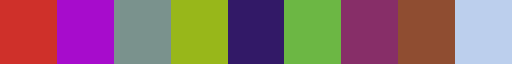

In [37]:
p.attrib_cmap

In [38]:
print(p.attrib_values)

['argile', 'tourbe', 'sable', 'gravier', 'silex', 'craie', 'marne', 'remblai', 'limon']


In [39]:
find_new_word_for_legend(p.legend_dict, p.repr_attribute)

[]

### Borehole log

In [40]:
bh_name = 'PT87'

/home/vleminckm/GSDMA/core/visual.py:285: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  attrib_values = list(pd.unique(attrib_values))  # to avoid duplicates


Attribute: 'lithology'





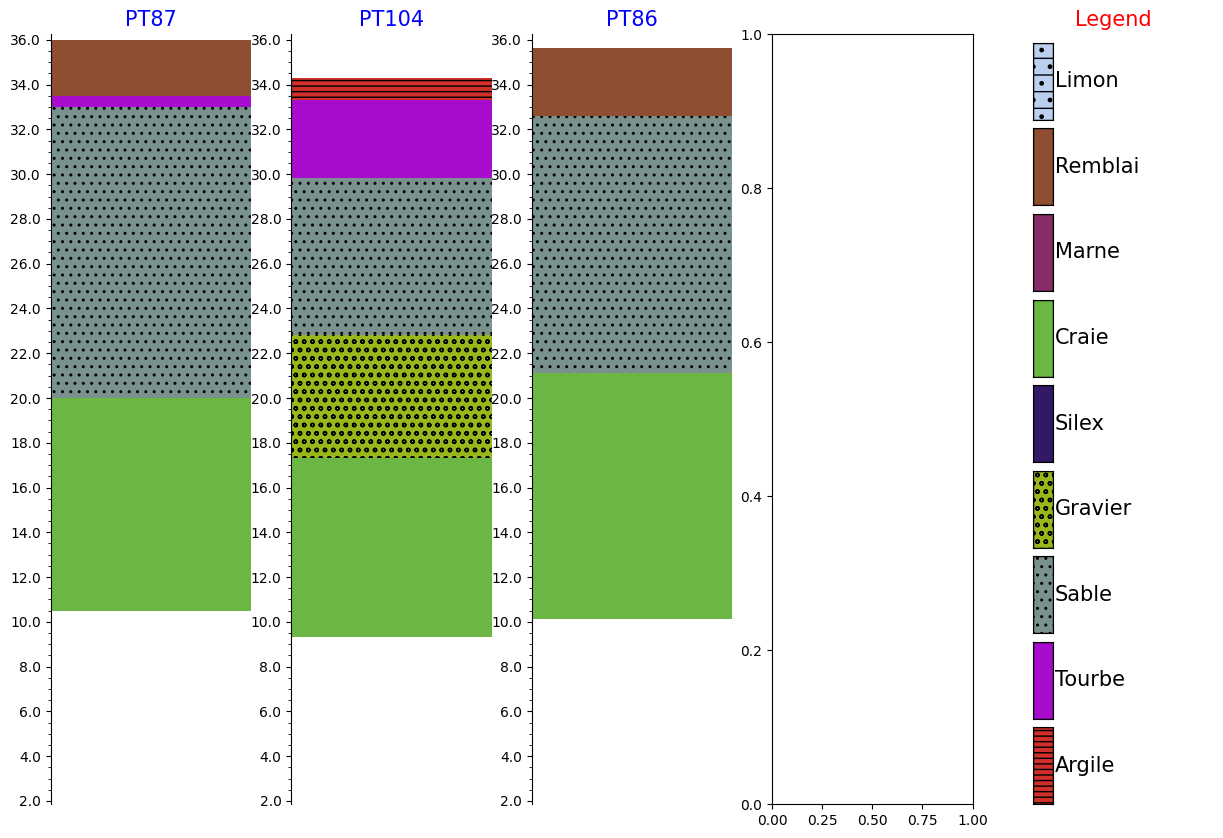

In [41]:
ticks=(0.5, 2)
bhs = [bh_name, 'PT104', 'PT86', 'F100']
p.plot_log(figsize=(15, 10), bh_names=bhs, ticks=ticks)#, ylim='auto')
# TODO: add a commit for this: enables representation of multiple boreholes (fixed on 2023/03/05)

In [42]:
p.boreholes_3d[bh_name].components

{0: [Component({'lithology': 'remblai'})],
 1: [Component({'lithology': 'tourbe'})],
 2: [Component({'lithology': 'sable'})],
 3: [Component({'lithology': 'craie'})]}

#### add ground surface to the plotter

In [43]:
pother_vtks = {'ground_surface':{'mesh':pv.read('data/grille_nimy.tiff'), 
                                'opacity':0.1}}

In [44]:
def get_gcps(filename):
    """
    Helper function retrieves the Ground Control
    Points of a GeoTIFF. Note that this requires gdal.
    """
    if rasterio is None:
        msg = "rasterio is required for this function"
        raise ImportError(msg)

    def get_point(gcp):
        return np.array([gcp.x, gcp.y, gcp.z])

    # Load a raster
    src = rasterio.open(filename)
    # Grab the Groung Control Points
    points = np.array([get_point(gcp) for gcp in src.gcps[0]])
    # Now Grab the three corners of their bounding box
    # -- This guarantees we grab the right points
    bounds = pv.PolyData(points).bounds
    origin = [bounds[0], bounds[2], bounds[4]]  # BOTTOM LEFT CORNER
    point_u = [bounds[1], bounds[2], bounds[4]]  # BOTTOM RIGHT CORNER
    point_v = [bounds[0], bounds[3], bounds[4]]  # TOP LEFT CORNER
    return origin, point_u, point_v

In [45]:
src = rasterio.open('data/grille_nimy.tiff')
transform = np.array(src.transform)

transform_matrix = np.array([[transform[0],transform[1],0.,transform[2]],[transform[3],transform[4],0.,transform[5]],[0.,0.,1.,0.],[0.,0.,0.,1.]])

In [46]:
src.bounds

BoundingBox(left=121011.0000682382, bottom=129504.99063498093, right=122446.0000682382, top=130294.99063498093)

In [47]:
img = pother_vtks['ground_surface']['mesh']
img = img.cast_to_structured_grid()
img.point_data['value']=img['Tiff Scalars']
img.transform(transform_matrix)
img.plot()

/tmp/ipykernel_295263/2284551870.py:4: PyVistaDeprecationWarning: The default value of `inplace` for the filter `StructuredGrid.transform` will change in the future. Previously it defaulted to `True`, but will change to `False`. Explicitly set `inplace` to `True` or `False` to silence this warning.
  img.transform(transform_matrix)
2026-05-12 17:16:14.291 (   2.390s) [    7FD3F63C6B80]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Widget(value='<iframe src="/user/vleminckm/proxy/41507/index.html?ui=P_0x7fd38392f0a0_0&reconnect=auto" class=…

In [48]:
v = img['value']
pts = pv.PointSet(img.points)
pts['value'] = img['Tiff Scalars']

In [49]:
nx, ny, nz = img.dimensions
x_step = (pts.bounds.x_max - pts.bounds.x_min)/(nx-1)
y_step = (pts.bounds.y_max - pts.bounds.y_min)/(ny-1)

In [50]:
xrng = np.linspace(pts.bounds.x_min-x_step/2, pts.bounds.x_max+x_step/2, nx+1)
yrng = np.linspace(pts.bounds.y_min-y_step/2, pts.bounds.y_max+ y_step/2, ny+1)
grid = pv.RectilinearGrid(xrng, yrng)
grid.cell_data['value'] = v
#grid.plot()

In [51]:
pts2 = img.points
pts2[:,2] = img['Tiff Scalars'] *100
pts2 = pv.PointSet(pts2)
x = pts2.cast_to_polydata().delaunay_2d()
#x.plot()

### Load and display Ordinary kriging results

In [52]:
src = rasterio.open('./data/Nimy_0_KO_pred.tiff')
v = src.read(1)
ny, nx = v.shape
transform = np.array(src.transform)
x_min = transform[2]
x_step = transform[0]
x_max = x_min + (nx-1) * x_step
y_max = transform[5]
y_step = transform[4]
y_min = y_max + (ny-1) * y_step
xrng = np.linspace(x_min-x_step/2, x_max+x_step/2, nx+1)
yrng = np.linspace(y_min-y_step/2, y_max+ y_step/2, ny+1)
scale_factor = 10.0
grid = pv.RectilinearGrid(xrng, yrng)
grid.cell_data['piezo [m]'] = np.flipud(v).flatten()
grid.set_active_scalars('piezo [m]')
#grid.plot()

(<FieldAssociation.CELL: 1>,
 pyvista_ndarray([30.486364, 30.486364, 30.486364, ..., 30.487015,
                  30.486868, 30.486738], shape=(82570,), dtype=float32))

In [53]:
grid = grid.cell_data_to_point_data(pass_cell_data='piezo [m]')
grid.warp_by_scalar('piezo [m]').transform(pv.Transform().scale(1.,1.,10.)).plot()

/tmp/ipykernel_295263/1330949947.py:2: PyVistaDeprecationWarning: The default value of `inplace` for the filter `StructuredGrid.transform` will change in the future. Previously it defaulted to `True`, but will change to `False`. Explicitly set `inplace` to `True` or `False` to silence this warning.
  grid.warp_by_scalar('piezo [m]').transform(pv.Transform().scale(1.,1.,10.)).plot()


Widget(value='<iframe src="/user/vleminckm/proxy/41507/index.html?ui=P_0x7fd388156830_1&reconnect=auto" class=…

In [54]:
src = rasterio.open('./data/Nimy_craie_KU_smooth.tiff')
top_craie = src.read(1)

ny, nx = top_craie.shape
transform = np.array(src.transform)
x_min = transform[2]
x_step = transform[0]
x_max = x_min + (nx-1) * x_step
y_max = transform[5]
y_step = transform[4]
y_min = y_max + (ny-1) * y_step
xrng = np.linspace(x_min-x_step/2, x_max+x_step/2, nx+1)
yrng = np.linspace(y_min-y_step/2, y_max+ y_step/2, ny+1)
gridx = pv.RectilinearGrid(xrng, yrng)
gridx.cell_data['Top craie [m]'] = np.flipud(top_craie).flatten()
gridx.set_active_scalars('Top craie [m]')
#gridx.plot()

(<FieldAssociation.CELL: 1>,
 pyvista_ndarray([18.681072, 18.687893, 18.701405, ..., 24.207602,
                  24.20612 , 24.205381], shape=(33852,), dtype=float32))

In [55]:
gridx = gridx.cell_data_to_point_data(pass_cell_data='Top craie [m]')
gridx.warp_by_scalar('Top craie [m]').transform(pv.Transform().scale(1.,1.,10.)).plot()

/tmp/ipykernel_295263/203076670.py:2: PyVistaDeprecationWarning: The default value of `inplace` for the filter `StructuredGrid.transform` will change in the future. Previously it defaulted to `True`, but will change to `False`. Explicitly set `inplace` to `True` or `False` to silence this warning.
  gridx.warp_by_scalar('Top craie [m]').transform(pv.Transform().scale(1.,1.,10.)).plot()


Widget(value='<iframe src="/user/vleminckm/proxy/41507/index.html?ui=P_0x7fd388154070_2&reconnect=auto" class=…

In [56]:
src = rasterio.open('./data/topo_recadree.tiff')
topo_recadree = src.read(1)

ny, nx = topo_recadree.shape
transform = np.array(src.transform)
x_min = transform[2]
x_step = transform[0]
x_max = x_min + (nx-1) * x_step
y_max = transform[5]
y_step = transform[4]
y_min = y_max + (ny-1) * y_step
xrng = np.linspace(x_min-x_step/2, x_max+x_step/2, nx+1)
yrng = np.linspace(y_min-y_step/2, y_max+ y_step/2, ny+1)
gridm = pv.RectilinearGrid(xrng, yrng)
gridm.cell_data['TOPO [m]'] = np.flipud(topo_recadree).flatten()
gridm.set_active_scalars('TOPO [m]')
#gridx.plot()

(<FieldAssociation.CELL: 1>,
 pyvista_ndarray([43.851498, 43.841297, 43.821465, ..., 37.363895,
                  37.331585, 37.32432 ], shape=(33852,), dtype=float32))

In [57]:
gridm = gridm.cell_data_to_point_data(pass_cell_data='TOPO [m]')
gridm.warp_by_scalar('TOPO [m]').transform(pv.Transform().scale(1.,1.,10.)).plot()

/tmp/ipykernel_295263/3851765706.py:2: PyVistaDeprecationWarning: The default value of `inplace` for the filter `StructuredGrid.transform` will change in the future. Previously it defaulted to `True`, but will change to `False`. Explicitly set `inplace` to `True` or `False` to silence this warning.
  gridm.warp_by_scalar('TOPO [m]').transform(pv.Transform().scale(1.,1.,10.)).plot()


Widget(value='<iframe src="/user/vleminckm/proxy/41507/index.html?ui=P_0x7fd3882d9240_3&reconnect=auto" class=…

In [58]:
other_vtks={}
other_vtks['KO_pred']={'mesh': grid.warp_by_scalar('piezo [m]').transform(pv.Transform().scale(1.,1.,1.)), 'opacity':0.5}
#other_vtks['test_eliot']={'mesh': img, 'opacity':0.5}
other_vtks['craie_KU']={'mesh': gridx.warp_by_scalar('Top craie [m]').transform(pv.Transform().scale(1.,1.,1.)), 'cmap' : 'terrain', 'opacity':1.0}
other_vtks['topo_recadree']={'mesh': gridm.warp_by_scalar('TOPO [m]').transform(pv.Transform().scale(1.,1.,1.)), 'cmap' : 'terrain', 'opacity':1.0}

/tmp/ipykernel_295263/3327630300.py:2: PyVistaDeprecationWarning: The default value of `inplace` for the filter `StructuredGrid.transform` will change in the future. Previously it defaulted to `True`, but will change to `False`. Explicitly set `inplace` to `True` or `False` to silence this warning.
  other_vtks['KO_pred']={'mesh': grid.warp_by_scalar('piezo [m]').transform(pv.Transform().scale(1.,1.,1.)), 'opacity':0.5}
/tmp/ipykernel_295263/3327630300.py:4: PyVistaDeprecationWarning: The default value of `inplace` for the filter `StructuredGrid.transform` will change in the future. Previously it defaulted to `True`, but will change to `False`. Explicitly set `inplace` to `True` or `False` to silence this warning.
  other_vtks['craie_KU']={'mesh': gridx.warp_by_scalar('Top craie [m]').transform(pv.Transform().scale(1.,1.,1.)), 'cmap' : 'terrain', 'opacity':1.0}
/tmp/ipykernel_295263/3327630300.py:5: PyVistaDeprecationWarning: The default value of `inplace` for the filter `StructuredGri

In [59]:
bh = p.boreholes_3d['PT104']

In [60]:
x = (bh._vtk.center[0], bh._vtk.center[1], bh.z_collar) 
x

(121792.0, 129926.0, 34.31474304199219)

In [61]:
bg_color = 'white'

p.plot_3d(bh_name_size=10, legend_title_size=25, legend_label_size=6, legend_vertical=True, 
          bg_color=bg_color, window_size=(800, 600), diam=0.2, smooth_shading=True,
         add_vtks_obj=other_vtks)

/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))


adding KO_pred ...
adding craie_KU ...
adding topo_recadree ...


* Change repr_attribute

In [62]:
attributes

['borehole_type', 'lithology']

In [63]:
bh_name = 'PT82'

In [64]:
p.boreholes_3d[bh_name]#.attrib_components()

<core.visual.Borehole3D> name: PT82 | length:25.50 m | 6 Intervals | start=35.48, stop=9.98

In [65]:
p.attrib_legend

Legend(Decor({'_colour': '#cf302a', 'width': 3, 'hatch': '---', 'component': Component({'lithology': 'argile'})})
Decor({'_colour': '#a70ccc', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'tourbe'})})
Decor({'_colour': '#7a928d', 'width': 3, 'hatch': '..', 'component': Component({'lithology': 'sable'})})
Decor({'_colour': '#98b71a', 'width': 3, 'hatch': 'oo', 'component': Component({'lithology': 'gravier'})})
Decor({'_colour': '#321967', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'silex'})})
Decor({'_colour': '#6cb744', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'craie'})})
Decor({'_colour': '#872e68', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'marne'})})
Decor({'_colour': '#8f4d31', 'width': 3, 'hatch': None, 'component': Component({'lithology': 'remblai'})})
Decor({'_colour': '#bccfed', 'width': 3, 'hatch': '-.', 'component': Component({'lithology': 'limon'})}))

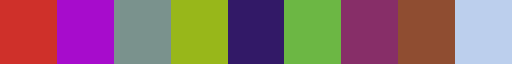

In [66]:
p.attrib_cmap

In [67]:
p.repr_attribute

'lithology'

In [68]:
p.boreholes_3d[bh_name].attrib_components

{0: Component({'lithology': 'remblai'}),
 1: Component({'lithology': 'limon'}),
 2: Component({'lithology': 'tourbe'}),
 3: Component({'lithology': 'sable'}),
 4: Component({'lithology': 'sable'}),
 5: Component({'lithology': 'craie'})}

In [69]:
p.attrib_values

['Argile',
 'Tourbe',
 'Sable',
 'Gravier',
 'Silex',
 'Craie',
 'Marne',
 'Remblai',
 'Limon']

/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:285: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  attrib_values = list(pd.unique(attrib_values))  # to avoid duplicates


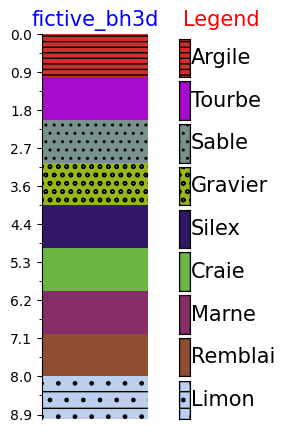

In [70]:
p.__fictive_bh3d__.plot_log()

### 3D display of project's boreholes

In [71]:
bh_name = 'PT87'

In [72]:
n = 'lithology' #'borehole_type'
if isinstance(n, str):
    n = attributes.index(n)

print('Chosen attribute is :', attributes[n])
p.repr_attribute = attributes[n]

/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))
/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.u

Chosen attribute is : lithology


In [73]:
bg_color = ["royalblue", "aliceblue"] #'white'
pl = pv.Plotter()
p.plot_3d(plotter=pl, window_size=(800, 600), diam=4.0, smooth_shading=True, bg_color=("white"), custom_legend=True, 
         add_vtks_obj=other_vtks, verbose=False)#, jupyter_backend='panel', verbose=False)
pl.set_scale(zscale=10.0)
pl.add_north_arrow_widget()
pl.show();

/home/vleminckm/GSDMA/core/visual.py:146: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  comp_list = list(pd.unique([c[repr_attribute] for c in components]))


adding KO_pred ...
adding craie_KU ...
adding topo_recadree ...


Widget(value='<iframe src="/user/vleminckm/proxy/41507/index.html?ui=P_0x7fd3882f29b0_4&reconnect=auto" class=…

A view with name (P_0x7fd3882f29b0_4) is already registered
 => returning previous one


Widget(value='<iframe src="/user/vleminckm/proxy/41507/index.html?ui=P_0x7fd3882f29b0_4&reconnect=auto" class=…

### 3D display of one borehole

In [82]:
p.boreholes_3d

{'PT101': <core.visual.Borehole3D> name: PT101 | length:24.50 m | 5 Intervals | start=32.84, stop=8.34,
 'PT102': <core.visual.Borehole3D> name: PT102 | length:24.00 m | 6 Intervals | start=31.71, stop=7.71,
 'PT104': <core.visual.Borehole3D> name: PT104 | length:24.00 m | 4 Intervals | start=33.31, stop=9.31,
 'PT106': <core.visual.Borehole3D> name: PT106 | length:21.60 m | 4 Intervals | start=31.38, stop=9.78,
 'PT107': <core.visual.Borehole3D> name: PT107 | length:23.00 m | 4 Intervals | start=30.91, stop=7.91,
 'PT108': <core.visual.Borehole3D> name: PT108 | length:23.30 m | 4 Intervals | start=31.92, stop=8.62,
 'PT109': <core.visual.Borehole3D> name: PT109 | length:30.90 m | 3 Intervals | start=31.62, stop=0.72,
 'PT110': <core.visual.Borehole3D> name: PT110 | length:21.30 m | 6 Intervals | start=31.97, stop=10.67,
 'PT111': <core.visual.Borehole3D> name: PT111 | length:24.00 m | 4 Intervals | start=32.17, stop=8.17,
 'PT112': <core.visual.Borehole3D> name: PT112 | length:23.50 m

In [83]:
p.boreholes_3d[bh_name].intervals[0]

Interval({'top': Position({'middle': 33.506195068359375, 'x': 121672.0, 'y': 130235.0, 'units': 'm'}), 'base': Position({'middle': 33.006195068359375, 'x': 121672.0, 'y': 130235.0, 'units': 'm'}), 'description': 'Tourbe', 'data': {}, 'components': [Component({'lithology': 'tourbe'})]})

In [93]:
p.boreholes_3d[bh_name].plot_3d(str_annotations=True, custom_legend=True)

Widget(value='<iframe src="/user/vleminckm/proxy/33021/index.html?ui=P_0x7ff3bf494220_13&reconnect=auto" class…

In [205]:
p.boreholes_3d[bh_name]._vtk

PolyData (0x7fcf05142080)
  N Cells:    156
  N Points:   600
  N Strips:   156
  X Bounds:   1.217e+05, 1.217e+05
  Y Bounds:   1.302e+05, 1.302e+05
  Z Bounds:   1.051e+01, 3.351e+01
  N Arrays:   3

In [95]:
p.boreholes_3d[bh_name]._vtk.CELL_DATA_FIELD #.get_array #geometry.data[2].array.array

2